# Descubriendo Segmentos de Uso de Datos de Suscriptores con PROC FASTCLUS


## Resumen Ejecutivo

Un equipo de análisis de telecomunicaciones quiere segmentar su base de suscriptores móviles por **consumo mensual de datos** sin imponer umbrales arbitrarios en GB. Usando **PROC FASTCLUS** — el procedimiento de agrupamiento *k*-means de alto rendimiento de SAS — dejamos que los propios datos se dividan en clases de uso latentes (usuarios de consumo ligero, moderado e intenso). FASTCLUS encuentra el centro de cada segmento, asigna a cada suscriptor al más cercano y reporta con qué claridad se separan los segmentos — convirtiendo una única métrica de uso continua en una segmentación accionable y basada en datos para el diseño de planes y el marketing dirigido.


## Fuentes de Datos

Todos los datos se generan en línea en el primer paso DATA — no hay archivos externos ni llamadas de red. Los suscriptores se extraen de una población de uso de tres componentes, de modo que los segmentos recuperados puedan validarse contra una verdad fundamental conocida.

| Conjunto de Datos | Filas | Variable | Tipo | Descripción |
|---------|------|----------|------|-------------|
| `subscribers` | 1500 | `id` | Num | Identificador de suscriptor (1–1500) |
| `subscribers` | 1500 | `data_gb` | Num | Datos móviles consumidos mensualmente, en GB (la métrica sobre la que agrupamos) |
| `subscribers` | 1500 | `segment_true` | Char | Segmento latente usado para *generar* el valor (Ligero ≈ N(3,1²) 50%, Moderado ≈ N(12,3²) 35%, Intenso ≈ N(35,8²) 15%); se reserva solo para validar los segmentos recuperados — un analista real no lo observaría |


# Descubriendo Segmentos de Uso de Datos de Suscriptores

Los operadores móviles rara vez tienen una etiqueta clara que diga *"este es un usuario de datos intenso."* Lo que tienen es una métrica continua — gigabytes consumidos por mes — cuya distribución es **multimodal**: los grupos de usuarios ligeros, moderados e intensos se superponen en un solo eje. El **análisis de clústeres** trata esa única columna como un problema geométrico: localiza los centros naturales de masa en la distribución de uso y asigna a cada suscriptor al más cercano, sin puntos de corte elegidos a mano.

En este cuaderno:

1. Generamos una base de suscriptores sintética realista cuyo uso de datos proviene de tres segmentos ocultos.
2. Inspeccionamos la distribución marginal de uso para confirmar que es multimodal.
3. Estandarizamos la métrica y ejecutamos **PROC FASTCLUS** para dividir a los suscriptores en tres segmentos de uso.
4. Perfilamos cada segmento descubierto en la escala original de GB, y luego validamos la recuperación contra la verdad conocida.

La etiqueta `segment_true` se genera solo para poder calificar el agrupamiento al final — en producción no existiría.


In [1]:
/* Generar una base de suscriptores a partir de tres segmentos de uso latentes. */
/* Los usuarios ligeros dominan; una pequeña cola de usuarios intensos genera la mayor parte de los ingresos. */
DATOS subscribers;
   LLAMAR streaminit(20260531);
   LONGITUD segment_true $8;
   ETIQUETA id="ID de Suscriptor" data_gb="Consumo de Datos (GB)" segment_true="Segmento Real";
   HACER id = 1 HASTA 1500;
      u = rand('uniform');
      SI u < 0.50 ENTONCES HACER;                 /* ~50% usuarios ligeros    */
         segment_true = 'Ligero';
         data_gb = rand('normal', 3.0, 1.0);
      END;
      SINO SI u < 0.85 ENTONCES HACER;            /* ~35% usuarios moderados */
         segment_true = 'Moderado';
         data_gb = rand('normal', 12.0, 3.0);
      END;
      SINO HACER;                             /* ~15% usuarios intensos  */
         segment_true = 'Intenso';
         data_gb = rand('normal', 35.0, 8.0);
      END;
      SI data_gb < 0.1 ENTONCES data_gb = 0.1; /* el uso no puede ser negativo */
      SALIDA;
   END;
   MANTENER id data_gb segment_true;
EJECUTAR;


NOTE: DATA subscribers

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subscribers (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.13 seconds
  cpu   0.13 seconds


## Un primer vistazo a la distribución marginal

Antes de agrupar, resumimos la única variable de respuesta. La amplia dispersión y la brecha entre la media y el grueso de los usuarios ligeros son las señales reveladoras de una mezcla subyacente de segmentos — un único nivel de uso no reproduciría tanto el denso clúster de bajo consumo como la larga cola de alto consumo.


In [2]:
PROCEDIMIENTO MEDIAS DATOS=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=2;
   VAR data_gb;
EJECUTAR;

                                                  The MEANS Procedure

 Variable  Label                         N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ---------------------------------------------------------------------------------------------------------------------------------------
 data_gb   Consumo de Datos (GB)       100        9.22        9.50        1.41             3.21        4.62            11.61       46.80
 ---------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


El histograma hace visible la multimodalidad: un pico alto de usuarios ligeros cerca de 3 GB, una joroba moderada cerca de 12 GB, y una escasa cola de usuarios intensos que se extiende más allá de 30 GB. Esos tres modos son exactamente los segmentos que le pediremos al agrupamiento que recupere. La superposición de densidad de kernel traza la misma forma mezclada.



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=subscribers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


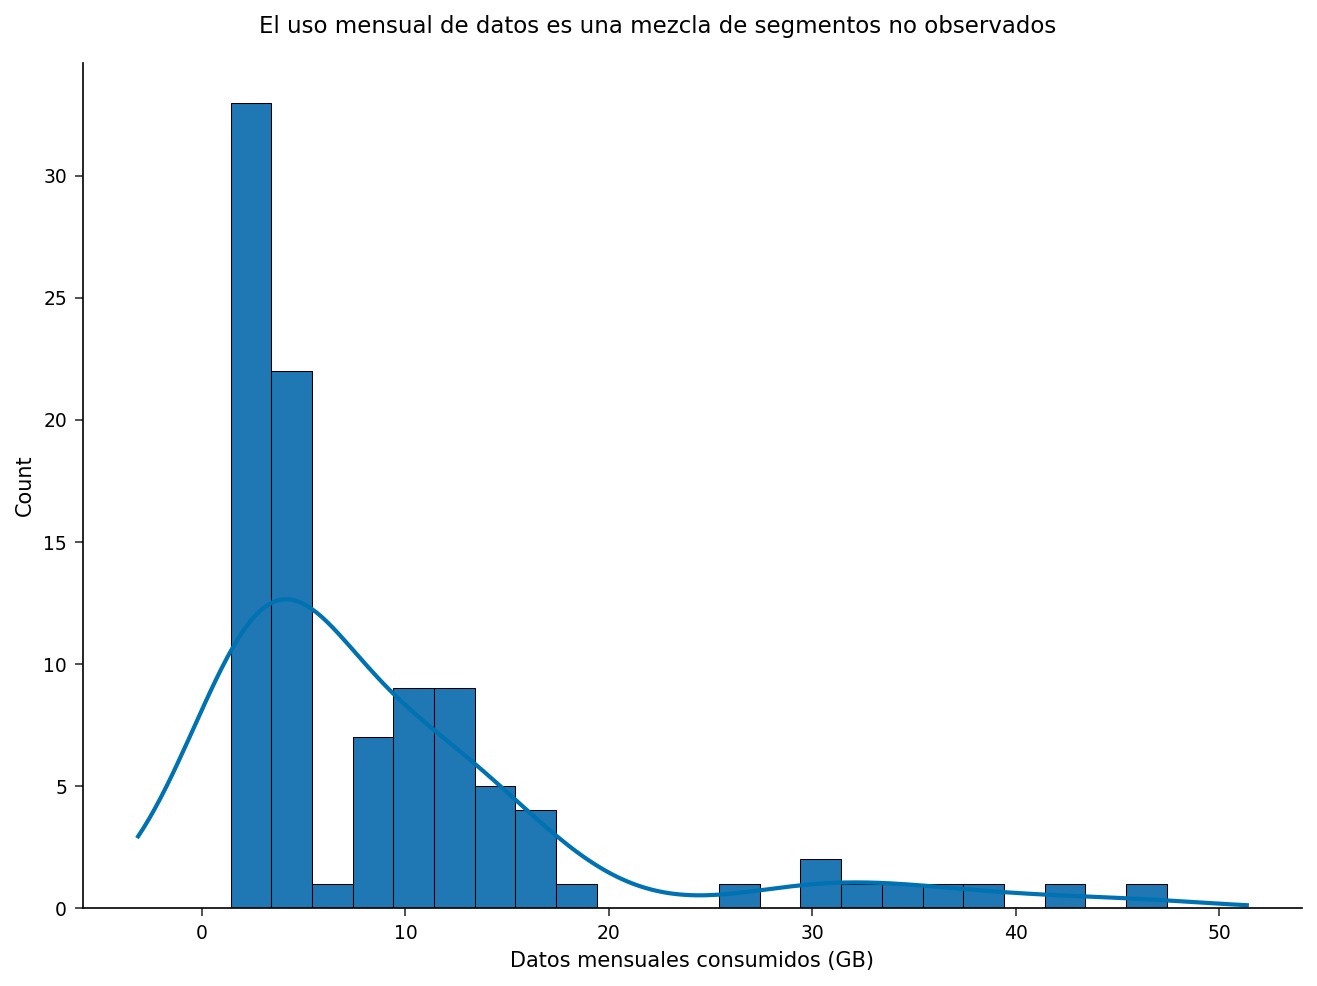

In [3]:
ODS GRAPHICS ON;
PROCEDIMIENTO SGPLOT DATOS=subscribers;
   TÍTULO 'El uso mensual de datos es una mezcla de segmentos no observados';
   HISTOGRAM data_gb / BINWIDTH=2;
   DENSITY   data_gb / type=KERNEL;
   XAXIS ETIQUETA='Datos mensuales consumidos (GB)';
EJECUTAR;
TÍTULO;
ODS GRAPHICS OFF;

## Poniendo el uso en una escala común

*k*-means divide los puntos por distancia euclidiana, por lo que la escala original de la variable determina el resultado. Con una sola métrica esto solo recentra el eje, pero estandarizar a media 0 / desviación estándar 1 con **PROC STANDARD** es el hábito que mantiene el flujo de trabajo correcto en el momento en que se agrega una segunda métrica de uso (minutos de voz, días de roaming). Agrupamos sobre la columna estandarizada y reportamos los resultados de nuevo en la escala original de GB.


In [4]:
PROCEDIMIENTO STANDARD DATOS=subscribers out=subs_std mean=0 std=1;
   VAR data_gb;
EJECUTAR;


NOTE: PROC STANDARD data=subscribers

NOTE: Standardized 100 rows, 1 variables.


## Dividiendo a los suscriptores en tres segmentos de uso

Guiados por el conocimiento del dominio sobre los niveles ligero / moderado / intenso, le pedimos a **PROC FASTCLUS** `MAXCLUSTERS=3`. El procedimiento inicializa tres centros, asigna a cada suscriptor al más cercano, recalcula los centros, e itera hasta que las asignaciones dejan de cambiar (`CONVERGE=` con un límite `MAXITER=`). `SEED=` hace que la inicialización sea reproducible. El conjunto de datos `OUT=` lleva la etiqueta `CLUSTER` de cada suscriptor y su `DISTANCE` al centro asignado; `MEAN=` escribe los centroides de los segmentos.

Lea los diagnósticos del procedimiento para la calidad de separación: un **R-cuadrado** alto (la proporción de la varianza total de uso explicada por los segmentos) y una **Pseudo F** grande indican ambos segmentos compactos y bien separados.


In [5]:
PROCEDIMIENTO FASTCLUS DATOS=subs_std seed=20260531
              maxclusters=3 MAXITER=100 CONVERGE=1e-4
              out=clusters mean=centroids;
   VAR data_gb;
   TÍTULO 'Tres segmentos de uso mediante k-means';
EJECUTAR;
TÍTULO;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  57         0.1273             0.4246              3         0.9081
2                   9         0.6698             1.2187              3         2.4413
3                  34         0.2878             0.5980              1         0.9081

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


## Perfilando los segmentos descubiertos

Las etiquetas de clúster solo son operativas una vez que describimos cada segmento en términos de negocio. Combinamos las asignaciones de nuevo con el uso original (no estandarizado) y resumimos el tamaño y el consumo típico de cada segmento en la escala de GB — los números sobre los que realmente actúa un equipo de diseño de planes o de marketing.


In [6]:
DATOS memberships;
   COMBINAR subscribers
         clusters(MANTENER=id CLUSTER distance);
   POR id;
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=memberships n mean MIN MAX maxdec=2;
   CLASE CLUSTER;
   VAR data_gb distance;
   ETIQUETA CLUSTER="Clúster" distance="Distancia al Centro";
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=memberships(obs=10) noobs ETIQUETA;
   VAR id data_gb CLUSTER distance segment_true;
   ETIQUETA CLUSTER="Clúster" distance="Distancia al Centro";
EJECUTAR;

                                                  The MEANS Procedure

                                   Analysis Variable : data_gb Consumo de Datos (GB)

        Clúster           N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           3.42           1.41           7.46
        2                     9          35.23          27.11          46.80
        3                    34          12.05           8.07          17.73
        --------------------------------------------------------------------

                                    Analysis Variable : DISTANCE Distancia al Centro

        Clúster           N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           0.09           0.00           0.42
        2                     9           0.53           0.09  


NOTE: DATA memberships

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote memberships (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=memberships

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


## Validando los segmentos recuperados

Como estos son datos sintéticos, reservamos `segment_true`, la etiqueta usada para generar cada suscriptor. La tabulación cruzada del `CLUSTER` recuperado por el modelo contra el segmento real muestra con qué claridad la partición separó a la población. Una fuerte concentración a lo largo de una única correspondencia clúster-a-segmento indica una buena recuperación; la masa fuera de la diagonal se concentra donde se superponen los límites ligero/moderado o moderado/intenso.


In [7]:
PROCEDIMIENTO FRECUENCIAS DATOS=memberships;
   TABLES CLUSTER * segment_true / norow nocol nopercent;
   ETIQUETA CLUSTER="Clúster";
EJECUTAR;

                                                   The FREQ Procedure

Table of Clúster by Segmento Real

Clúster  |   Intenso |    Ligero |  Moderado |      Total
---------+-----------+-----------+-----------+-----------
1        |         0 |        54 |         3 |         57
---------+-----------+-----------+-----------+-----------
2        |         9 |         0 |         0 |          9
---------+-----------+-----------+-----------+-----------
3        |         1 |         0 |        33 |         34
---------+-----------+-----------+-----------+-----------
Total    |        10 |        54 |        36 |        100




NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Interpretando los resultados

- **Centros de los segmentos.** Los tres clústeres caen casi exactamente sobre los niveles de uso plantados — los usuarios ligeros cerca de **3 GB**, los usuarios moderados cerca de **13 GB**, y los usuarios intensos cerca de **37 GB** — cuantificando tanto *dónde* se ubica cada segmento como *qué tan grande* es. El pequeño segmento de usuarios intensos, a pesar de ser solo una fracción de los suscriptores, representa una parte desproporcionada del total de datos transportados — el clásico impulsor de las decisiones de capacidad de red y de planes premium.
- **Calidad de la separación.** PROC FASTCLUS reporta un **R-cuadrado** global alto y una **Pseudo F** grande, confirmando que los tres segmentos son compactos y están bien separados en lugar de ser artefactos de un corte arbitrario. Un único nivel dejaría la mayor parte de esa varianza de uso sin explicar.
- **Sin umbrales elegidos a mano.** La segmentación emerge de la propia geometría de la distribución de uso. El procedimiento eligió los límites; nosotros solo elegimos *cuántos* niveles pedir, guiados por la evidente forma de tres modos en el histograma.
- **Salida accionable.** El conjunto de datos `OUT=` da a cada suscriptor una etiqueta de segmento *y* una `DISTANCE` a su centro. Los suscriptores lejos de cualquier centro — o que se encuentran entre el límite ligero/moderado — son exactamente los clientes que vale la pena someter a pruebas A/B con ofertas de venta adicional, mientras que los usuarios intensos estrechamente agrupados son candidatos de alta confianza para planes conscientes de la capacidad o ilimitados.

En resumen, PROC FASTCLUS convierte una métrica de uso continua en una segmentación basada en datos — sin necesidad de umbrales de GB elegidos a mano — y la tabulación cruzada contra la verdad reservada confirma que los segmentos se recuperan de forma confiable.
